In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from protac_permeability.chem_utils import canonicalize_smiles, descriptor_functions, butina_groups
from rdkit import Chem
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score, mean_squared_error
from protac_permeability.permeability_surrogate import EnsemblePermeabilitySurrogate, PermeabilitySurrogate
from protac_permeability.plot_style import apply_style, PLOT_PALETTE, add_panel_label, DARK_SLATE
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
apply_style()

In [ ]:
ALL_DATA_PATH = Path("../data/combined_protacs.csv")
Path("../figures").mkdir(exist_ok=True)

In [3]:
new_protacs = pd.read_csv(ALL_DATA_PATH)
new_protacs["SMILES"] = new_protacs["SMILES"].apply(canonicalize_smiles)

In [4]:
new_protacs.columns[9:]

Index(['MolecularWeight', 'CharVol', 'cLogP', 'HeavyAtomCount', 'RingCount',
       'HydrogenBondAcceptorCount', 'HydrogenBondDonorCount',
       'RotatableBondCount', 'TopologicalPolarSurfaceArea', 'FractionCSP3',
       'NumStereoCenters', 'AllBonds', 'RingAtoms', 'Halogens', 'HeteroAtoms',
       'TNSA', 'Flexibility'],
      dtype='str')

In [5]:
new_protacs["SMILES"] = new_protacs.SMILES

protacs_features_2d = new_protacs[new_protacs.columns[9:]]

In [6]:
protacs_features_2d.columns = list(descriptor_functions.keys())

In [7]:
protacs_features_2d["SMILES"] = new_protacs.SMILES
protacs_features_2d["protac_id"] = new_protacs.protac_id
protacs_features_2d["protac_db_id"] = new_protacs.protac_db_id
protacs_features_2d["logPAMPA"] = new_protacs.logPAMPA
protacs_features_2d["origin"] = np.where(new_protacs.protac_db_id.isna(), "new", "protacdb")

In [8]:
old_protacs = new_protacs[protacs_features_2d["origin"] == "protacdb"]

In [9]:
new_protacs[new_protacs.protac_db_id.isna() & (new_protacs.logPAMPA > -6)].E3_ligase.value_counts()

E3_ligase
VHL     5
CRBN    3
Name: count, dtype: int64

In [10]:
new_protacs.original_pampa.str.startswith("<").sum() + new_protacs.original_pampa.str.startswith(">").sum()

np.int64(19)

In [11]:
mols_old = [Chem.MolFromSmiles(s) for s in old_protacs.SMILES]
mols_new = [Chem.MolFromSmiles(s) for s in new_protacs.SMILES]

In [12]:
SIZE=6

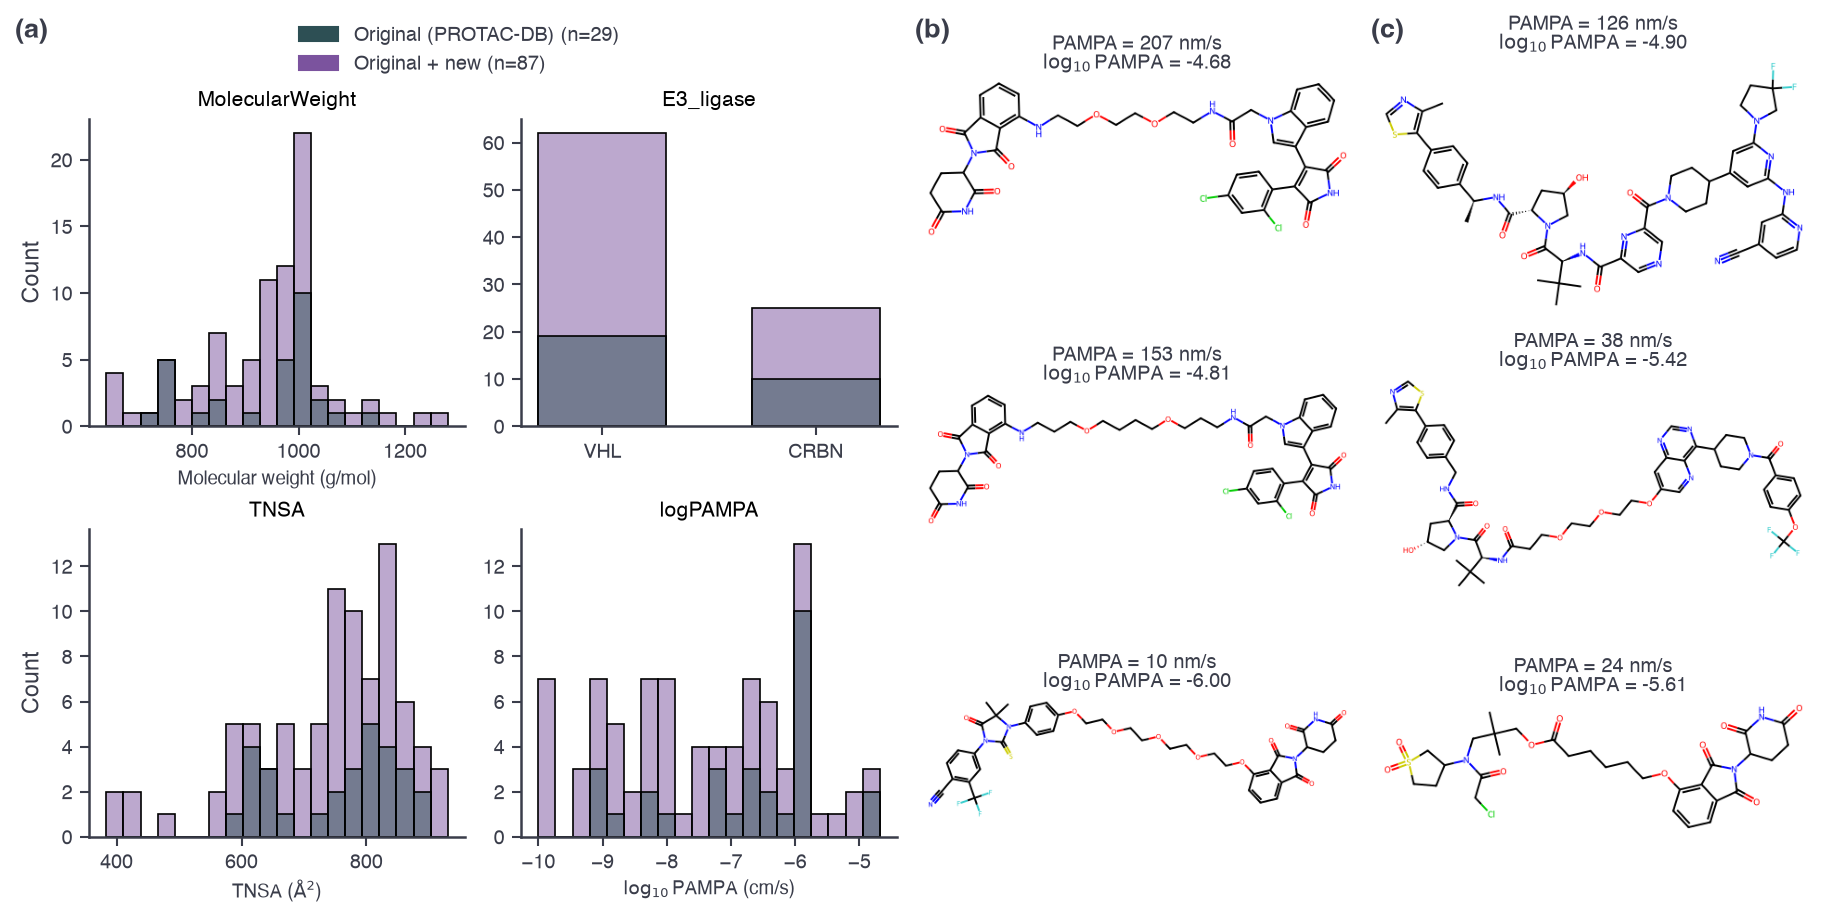

In [13]:
def trim_whitespace(img, pad=8):
    arr = np.array(img.convert("RGB"))
    mask = np.any(arr < 250, axis=-1)
    rows = np.where(np.any(mask, axis=1))[0]
    cols = np.where(np.any(mask, axis=0))[0]
    r0, r1 = max(rows[0] - pad, 0), min(rows[-1] + pad, arr.shape[0])
    c0, c1 = max(cols[0] - pad, 0), min(cols[-1] + pad, arr.shape[1])
    return img.crop((c0, r0, c1, r1))


descriptor_cols = ["MolecularWeight", "TNSA", "logPAMPA"]

group_order = ["Original", "Current"]
group_colors = {"Original": PLOT_PALETTE[0], "Current": PLOT_PALETTE[1]}
group_labels = {
    "Original": f"Original (PROTAC-DB) (n={len(old_protacs)})",
    "Current": f"Original + new (n={len(new_protacs)})",
}

descriptor_long = pd.concat(
    [
        protacs_features_2d.loc[protacs_features_2d.origin == "protacdb", descriptor_cols].assign(group="Original"),
        protacs_features_2d[descriptor_cols].assign(group="Current"),
    ],
    ignore_index=True,
).melt(id_vars="group", value_vars=descriptor_cols, var_name="descriptor", value_name="value")

ligase_order = ["VHL", "CRBN"]
ligase_long = pd.concat(
    [
        old_protacs[["E3_ligase"]].assign(group="Original"),
        new_protacs[["E3_ligase"]].assign(group="Current"),
    ],
    ignore_index=True,
)
ligase_long["E3_ligase"] = pd.Categorical(ligase_long["E3_ligase"], categories=ligase_order, ordered=True)

axis_units = {
    "MolecularWeight": "Molecular weight (g/mol)",
    "TNSA": r"TNSA ($\mathrm{\AA}^2$)",
    "logPAMPA": r"$\log_{10}$PAMPA (cm/s)",
    "E3_ligase": "",
}

top_old = old_protacs.sort_values(by="PAMPA", ascending=False).head(3)
top_new = new_protacs.sort_values(by="PAMPA", ascending=False).iloc[[2, 5, 6]]

fig = plt.figure(figsize=(2 * SIZE, SIZE), layout="constrained")
subfig_descriptors, subfig_old, subfig_new = fig.subfigures(
    1, 3, width_ratios=[2, 1, 1], wspace=0.02
)

# (a) descriptor distributions
axes_descriptors = subfig_descriptors.subplots(2, 2)
panel_cols = ["MolecularWeight", "E3_ligase", "TNSA", "logPAMPA"]
for i, (ax, col) in enumerate(zip(axes_descriptors.flat, panel_cols)):
    if col == "E3_ligase":
        sns.histplot(
            data=ligase_long, x="E3_ligase",
            stat="count", discrete=True, shrink=0.6,
            hue="group", hue_order=group_order, common_norm=False,
            legend=False, linewidth=0.8, ax=ax,
            multiple="layer"
        )
    else:
        sns.histplot(
            data=descriptor_long[descriptor_long.descriptor == col],
            x="value", stat="count", bins=20,
            hue="group", hue_order=group_order, common_norm=False,
            legend=False, linewidth=0.8, ax=ax,
            multiple="layer"
        )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(axis_units[col], fontsize=9)
    ax.set_ylabel("Count" if i % 2 == 0 else "")
    sns.despine(ax=ax)

subfig_descriptors.legend(
    handles=[Patch(color=group_colors[g], label=group_labels[g]) for g in group_order],
    loc="outside upper center", ncol=1, frameon=False,
)

for subfig_col, top_df in [(subfig_old, top_old), (subfig_new, top_new)]:
    for ax, row in zip(subfig_col.subplots(3, 1), top_df.itertuples()):
        mol = Chem.MolFromSmiles(row.SMILES)
        img = trim_whitespace(Chem.Draw.MolToImage(mol, size=(500, 500)))
        ax.imshow(img)
        ax.set_aspect("equal")
        ax.axis("off")
        pampa = row.PAMPA
        ax.set_title(
            "PAMPA" + f" = {pampa:.0f} nm/s\n" + r"$\log_{10}$PAMPA" + f" = {row.logPAMPA:.2f}",
            fontsize=9.5, color=DARK_SLATE, pad=0,
        )

for subfig, label in [(subfig_descriptors, "(a)"), (subfig_old, "(b)"), (subfig_new, "(c)")]:
    subfig.text(
        0.0, 0.99, label,
        fontsize=13, fontweight="bold", va="top", ha="left", color=DARK_SLATE,
    )

fig.savefig("../figures/data.pdf", bbox_inches="tight", dpi=600)

In [14]:
df = pd.read_csv(ALL_DATA_PATH)
mean_pred = df.logPAMPA.mean()
print(f"Mean predicted permeability: {mean_pred:.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(df.logPAMPA, [mean_pred] * len(df))):.2f}")

Mean predicted permeability: -7.43
RMSE: 1.42


In [15]:
new_model = EnsemblePermeabilitySurrogate.from_directory("../models/ensemble_full")
orig_model = EnsemblePermeabilitySurrogate.from_directory("../models/ensemble_original")
y = df.logPAMPA.values

In [16]:
descriptor_cols = list(descriptor_functions.keys())

In [17]:
from protac_permeability.permeability_surrogate.fit_surrogate import fit_ensemble

df = pd.read_csv(ALL_DATA_PATH)
y = df.logPAMPA.values
num_repeats = 5
print("All on all")
fit_ensemble(ALL_DATA_PATH, save_dir="../models/test", split_save_dir="../splits//test", n_models=5, num_repeats=num_repeats, descriptor_cols=descriptor_cols)
print()
print("New on all")
fit_ensemble(ALL_DATA_PATH, save_dir="../models/test_new", split_save_dir="../splits//test_new", n_models=5, num_repeats=num_repeats, new_only=True, descriptor_cols=descriptor_cols)
print()
print("Protac-db on all")
_ = fit_ensemble(ALL_DATA_PATH, save_dir="../models/test_orig", split_save_dir="../splits//test_orig", n_models=5, original_only=True, num_repeats=num_repeats, descriptor_cols=descriptor_cols)

All on all
Mean Spearman correlation: 0.53 ± 0.04
Mean RMSE: 1.23 ± 0.04
Mean R2: 0.24 ± 0.05

New on all
Mean Spearman correlation: 0.50 ± 0.05
Mean RMSE: 1.35 ± 0.04
Mean R2: 0.09 ± 0.05

Protac-db on all
Mean Spearman correlation: 0.36 ± 0.03
Mean RMSE: 1.64 ± 0.03
Mean R2: -0.34 ± 0.05


In [18]:
from protac_permeability.permeability_surrogate.fit_surrogate import fit_ensemble

num_repeats = 5

fit_ensemble(ALL_DATA_PATH, save_dir="../models/test_butina", split_save_dir="../splits//test_butina", n_models=5, num_repeats=num_repeats, descriptor_cols=descriptor_cols, dist_threshold=0.35)
fit_ensemble(ALL_DATA_PATH, save_dir="../models/test_new_butina", split_save_dir="../splits//test_new_butina", n_models=5, num_repeats=num_repeats, new_only=True, descriptor_cols=descriptor_cols, dist_threshold=0.35)
_ = fit_ensemble(ALL_DATA_PATH, save_dir="../models/test_orig_butina", split_save_dir="../splits//test_orig_butina", n_models=5, original_only=True, num_repeats=num_repeats, descriptor_cols=descriptor_cols, dist_threshold=0.35)

Mean Spearman correlation: 0.35 ± 0.06
Mean RMSE: 1.38 ± 0.02
Mean R2: 0.06 ± 0.03
Mean Spearman correlation: 0.28 ± 0.06
Mean RMSE: 1.48 ± 0.07
Mean R2: -0.09 ± 0.10
Mean Spearman correlation: 0.22 ± 0.06
Mean RMSE: 1.67 ± 0.07
Mean R2: -0.39 ± 0.12


In [19]:
results = []
dist_thresholds = np.arange(0.05, 0.65, 0.05)
threshold_results = {}
for dist_threshold in dist_thresholds:
    threshold_results[dist_threshold] = {}
    threshold_results[dist_threshold]["test"] = fit_ensemble(ALL_DATA_PATH, save_dir=f"../models/test_{dist_threshold}", split_save_dir=f"../splits//test_{dist_threshold}", n_models=5, num_repeats=num_repeats, dist_threshold=dist_threshold, descriptor_cols=descriptor_cols)
    threshold_results[dist_threshold]["test_new"] = fit_ensemble(ALL_DATA_PATH, save_dir=f"../models/test_new_{dist_threshold}", split_save_dir=f"../splits//test_new_{dist_threshold}", n_models=5, num_repeats=num_repeats, new_only=True, dist_threshold=dist_threshold, descriptor_cols=descriptor_cols)
    threshold_results[dist_threshold]["test_orig"] = fit_ensemble(ALL_DATA_PATH, save_dir=f"../models/test_orig_{dist_threshold}", split_save_dir=f"../splits//test_orig_{dist_threshold}", n_models=5, original_only=True, num_repeats=num_repeats, dist_threshold=dist_threshold, descriptor_cols=descriptor_cols)

Mean Spearman correlation: 0.48 ± 0.03
Mean RMSE: 1.29 ± 0.04
Mean R2: 0.17 ± 0.05
Mean Spearman correlation: 0.44 ± 0.03
Mean RMSE: 1.43 ± 0.05
Mean R2: -0.02 ± 0.07
Mean Spearman correlation: 0.36 ± 0.02
Mean RMSE: 1.67 ± 0.01
Mean R2: -0.39 ± 0.01
Mean Spearman correlation: 0.43 ± 0.03
Mean RMSE: 1.33 ± 0.04
Mean R2: 0.12 ± 0.05
Mean Spearman correlation: 0.41 ± 0.07
Mean RMSE: 1.46 ± 0.06
Mean R2: -0.06 ± 0.09
Mean Spearman correlation: 0.36 ± 0.02
Mean RMSE: 1.65 ± 0.03
Mean R2: -0.35 ± 0.05
Mean Spearman correlation: 0.43 ± 0.03
Mean RMSE: 1.32 ± 0.03
Mean R2: 0.14 ± 0.03
Mean Spearman correlation: 0.39 ± 0.05
Mean RMSE: 1.49 ± 0.07
Mean R2: -0.10 ± 0.11
Mean Spearman correlation: 0.37 ± 0.04
Mean RMSE: 1.59 ± 0.07
Mean R2: -0.25 ± 0.11
Mean Spearman correlation: 0.23 ± 0.06
Mean RMSE: 1.51 ± 0.05
Mean R2: -0.13 ± 0.08
Mean Spearman correlation: 0.16 ± 0.04
Mean RMSE: 1.65 ± 0.08
Mean R2: -0.36 ± 0.13
Mean Spearman correlation: 0.28 ± 0.04
Mean RMSE: 1.69 ± 0.07
Mean R2: -0.42 ± 

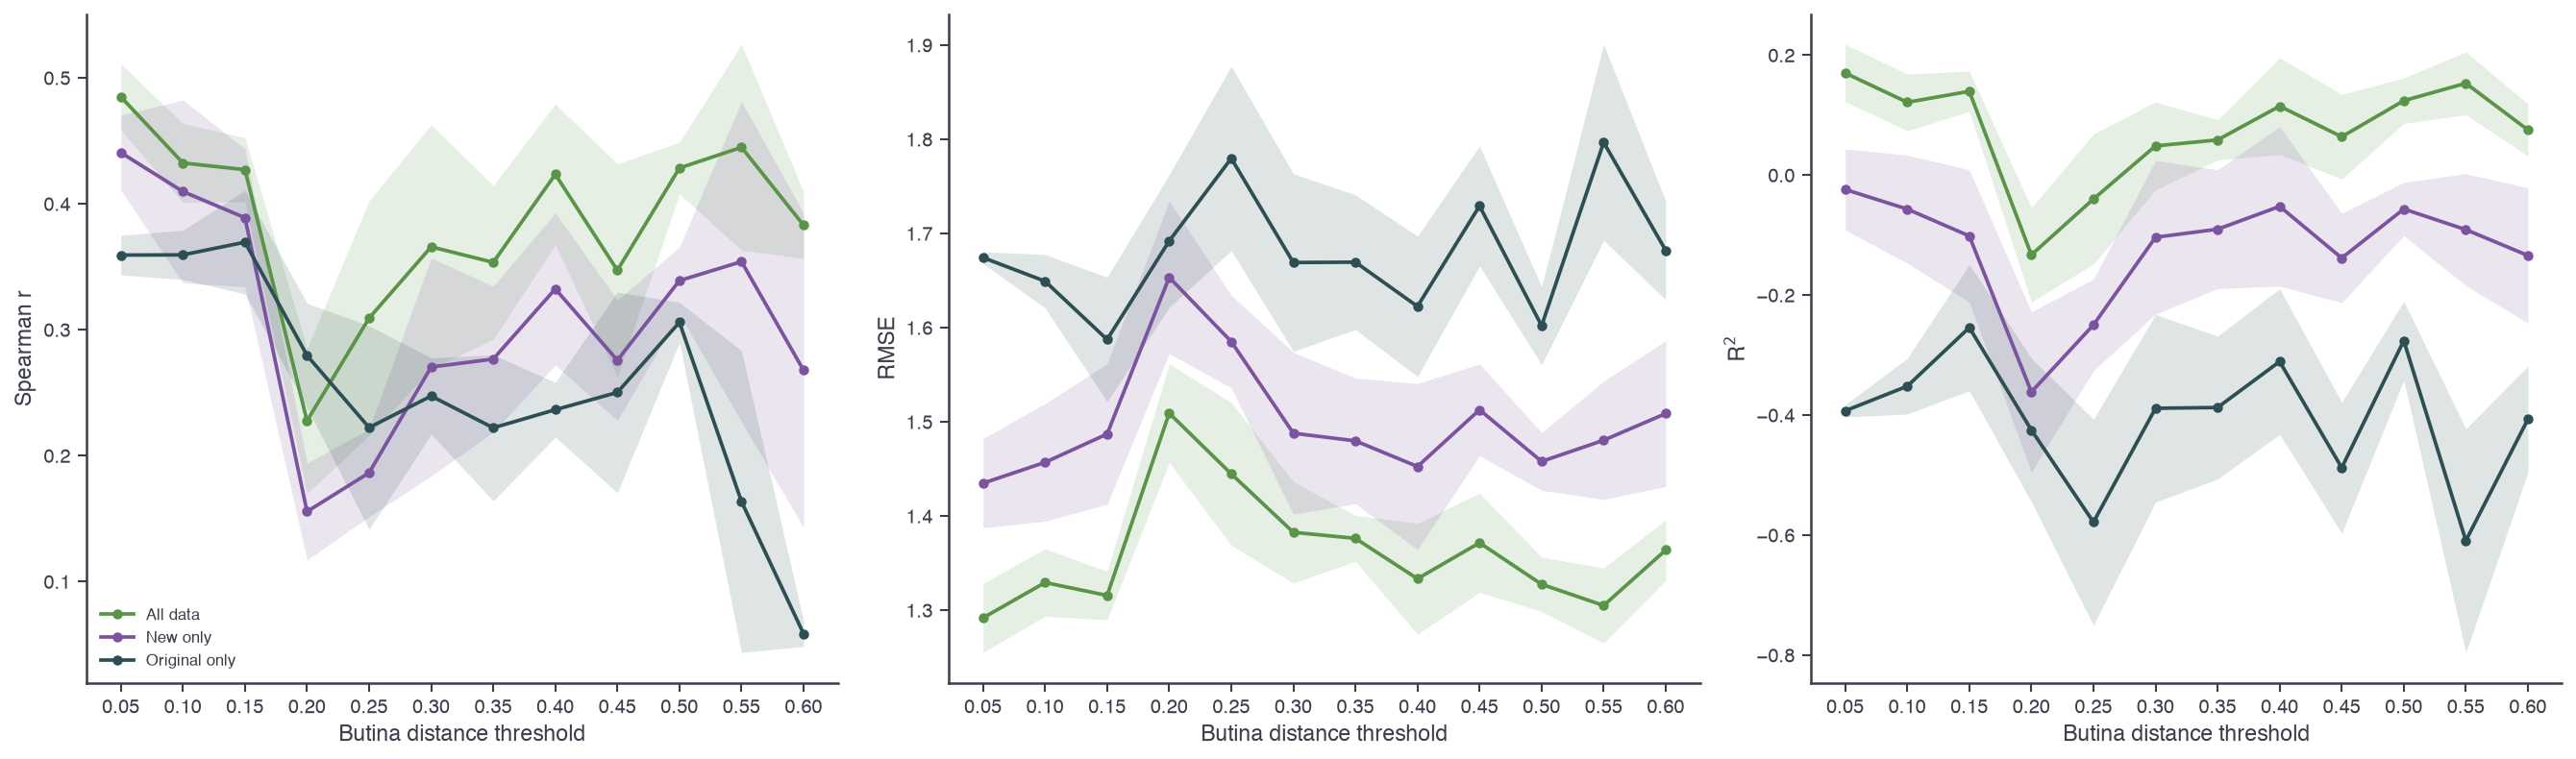

In [20]:
metric_names = ["Spearman r", "RMSE", r"R$^2$"]
model_order = ["test", "test_new", "test_orig"]
model_labels = {"test": "All data", "test_new": "New only", "test_orig": "Original only"}
model_colors = {"test": PLOT_PALETTE[3], "test_new": PLOT_PALETTE[1], "test_orig": PLOT_PALETTE[0]}

threshold_long = pd.DataFrame([
    {"dist_threshold": dist_threshold, "model": model_key, "metric": metric_name, "mean": mean_val, "std": std_val}
    for dist_threshold, model_dict in threshold_results.items()
    for model_key, metrics in model_dict.items()
    for metric_name, (mean_val, std_val) in zip(metric_names, metrics)
])

fig, axes = plt.subplots(1, 3, figsize=(3 * SIZE, SIZE * 0.9))
for ax, metric_name in zip(axes, metric_names):
    for model_key in model_order:
        sub = threshold_long[
            (threshold_long.model == model_key) & (threshold_long.metric == metric_name)
        ].sort_values("dist_threshold")
        ax.plot(
            sub.dist_threshold, sub["mean"], marker="o", markersize=4,
            color=model_colors[model_key], label=model_labels[model_key],
        )
        ax.fill_between(
            sub.dist_threshold, sub["mean"] - sub["std"], sub["mean"] + sub["std"],
            color=model_colors[model_key], alpha=0.15, linewidth=0,
        )
    ax.set_xticks(dist_thresholds)
    ax.set_xlabel("Butina distance threshold")
    ax.set_ylabel(metric_name)
    sns.despine(ax=ax)

axes[0].legend(loc="best", fontsize=8, frameon=False)

fig.tight_layout()
fig.savefig("../figures/threshold_metrics.pdf", bbox_inches="tight", dpi=600)

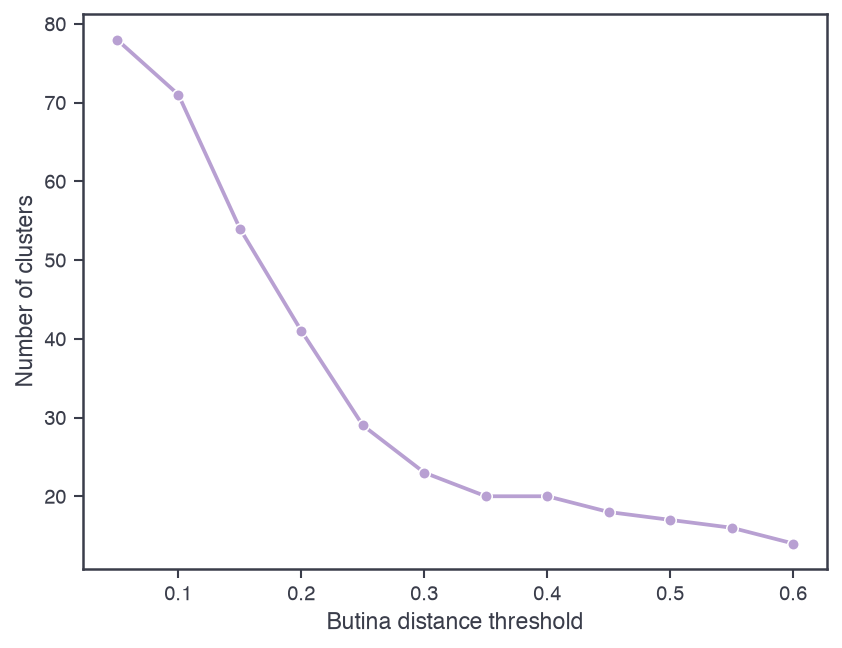

In [21]:
num_clusters = []
dist_thresholds = np.arange(0.05, 0.65, 0.05)
for dist_threshold in dist_thresholds:
    _, clusters = butina_groups(new_protacs.SMILES.values, dist_threshold)
    num_clusters.append(len(clusters))


sns.lineplot(x=dist_thresholds, y=num_clusters, marker="o", color=PLOT_PALETTE[2])
plt.xlabel("Butina distance threshold")
plt.ylabel("Number of clusters")
plt.savefig("../figures/num_clusters.pdf", bbox_inches="tight", dpi=600)

In [22]:
def get_preds(model, path):
    df = pd.read_csv(path)
    X = df[descriptor_cols].values
    preds_mean = model.predict(X)
    return df.protac_id.values, preds_mean

splits = sorted(Path("../splits//test/test").iterdir(), key=lambda x: int(x.stem.split('_')[1]))
models = sorted(Path("../models/test").iterdir(), key=lambda x: int(x.stem.split('_')[1]))
preds_all = np.zeros((num_repeats, len(new_protacs)), dtype=float)
for i, (model, split) in enumerate(zip(models, splits)):
    model = PermeabilitySurrogate.from_file(model)
    idx, preds = get_preds(model, split)
    repeat_id = i // 5
    assert np.all(preds_all[repeat_id, idx] == 0)
    preds_all[repeat_id, idx] = preds

splits = sorted(Path("../splits//test_new/test").iterdir(), key=lambda x: int(x.stem.split('_')[1]))
models = sorted(Path("../models/test_new").iterdir(), key=lambda x: int(x.stem.split('_')[1]))
preds_new = np.zeros((num_repeats, len(new_protacs)), dtype=float)
for i, (model, split) in enumerate(zip(models, splits)):
    model = PermeabilitySurrogate.from_file(model)
    idx, preds = get_preds(model, split)
    repeat_id = i // 5
    assert np.all(preds_new[repeat_id, idx] == 0)
    preds_new[repeat_id, idx] = preds


splits = sorted(Path("../splits//test_orig/test").iterdir(), key=lambda x: int(x.stem.split('_')[1]))
models = sorted(Path("../models/test_orig").iterdir(), key=lambda x: int(x.stem.split('_')[1]))
preds_orig = np.zeros((num_repeats, len(new_protacs)), dtype=float)
for i, (model, split) in enumerate(zip(models, splits)):
    model = PermeabilitySurrogate.from_file(model)
    idx, preds = get_preds(model, split)
    repeat_id = i // 5
    assert np.all(preds_orig[repeat_id, idx] == 0)
    preds_orig[repeat_id, idx] = preds

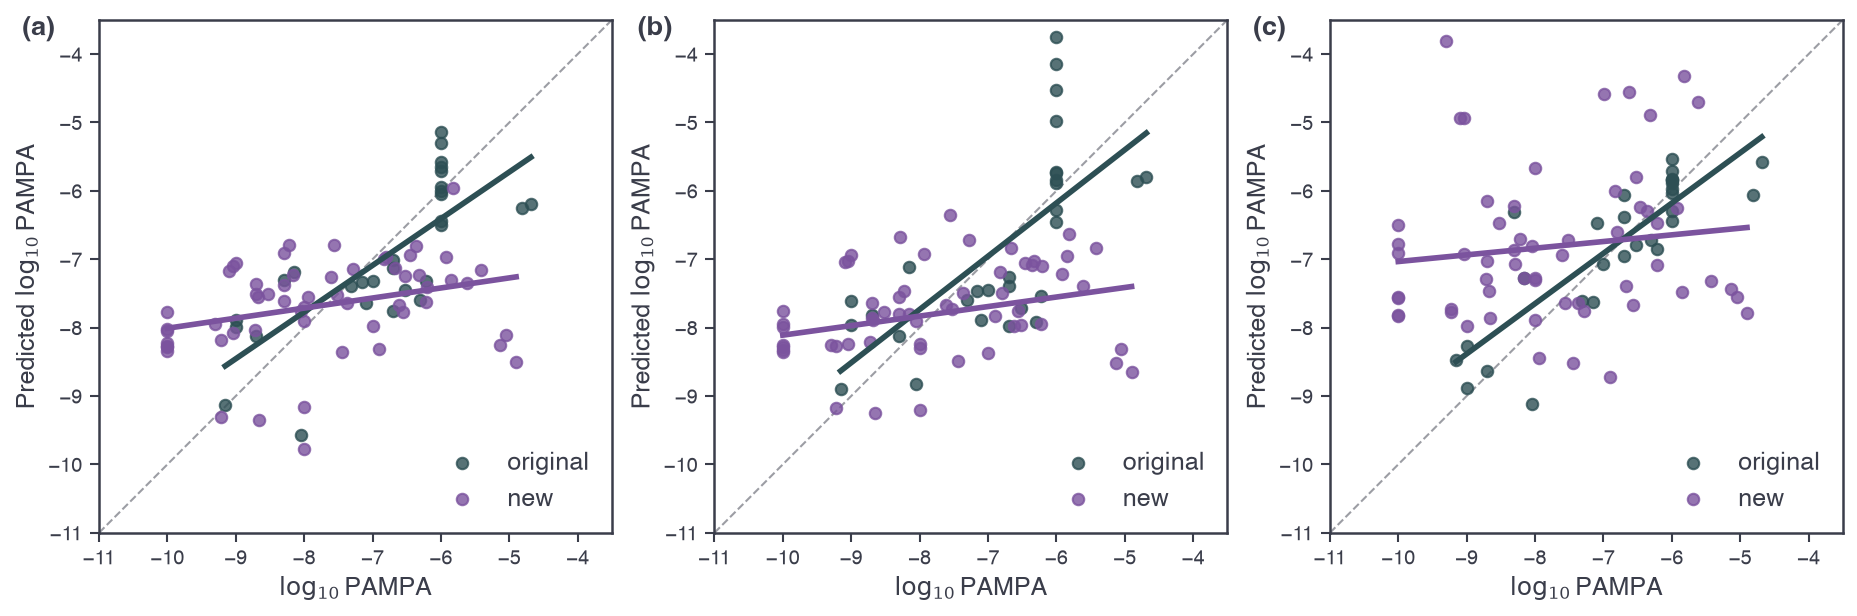

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(3 * (SIZE - 1), (SIZE - 1)))
LIM = (-11, -3.5)
POINT_COLOR = PLOT_PALETTE[1]
protac_ids = new_protacs["protac_id"].values
smiles_arr = new_protacs["SMILES"].values

hue = df["E3_ligase"].values
df["origin"] = np.where(df["protac_db_id"].isna(), "new", "protacdb")
hue = df["origin"]
origin = df["origin"].values

def get_metrics(y_true, y_pred):
    print(f"Spearman: {np.mean([spearmanr(y_true, p)[0] for p in y_pred]):.2f} ± {np.std([spearmanr(y_true, p)[0] for p in y_pred]):.2f}")
    print(f"RMSE: {np.mean([np.sqrt(mean_squared_error(y_true, p)) for p in y_pred]):.2f} ± {np.std([np.sqrt(mean_squared_error(y_true, p)) for p in y_pred]):.2f}")
    print(f"R²: {np.mean([r2_score(y_true, p) for p in y_pred]):.2f} ± {np.std([r2_score(y_true, p) for p in y_pred]):.2f}")

def make_plot(preds, y, origin, ax):
    sns.regplot(x=y[origin == "protacdb"], y=preds[origin == "protacdb"], ax=ax, scatter=True, scatter_kws={"color": PLOT_PALETTE[0]}, line_kws={"color": PLOT_PALETTE[0]}, ci=None, label="original")
    sns.regplot(x=y[origin == "new"], y=preds[origin == "new"], ax=ax, scatter=True, scatter_kws={"color": PLOT_PALETTE[1]}, line_kws={"color": PLOT_PALETTE[1]}, ci=None, label="new")
    ax.plot(LIM, LIM, linestyle="--", color=DARK_SLATE, linewidth=1, alpha=0.5, zorder=0)
    ax.legend(loc="lower right", fontsize=12, frameon=False)
    ax.set_ylabel(r"Predicted $\log_{10}$PAMPA", fontsize=12)
    ax.set_xlabel(r"$\log_{10}$PAMPA", fontsize=12)
    ax.set_ylim(LIM)
    ax.set_xlim(LIM)
    ax.grid(False)
    ax.set_box_aspect(1)

make_plot(preds_all.mean(axis=0), y, origin, ax[0])
make_plot(preds_new.mean(axis=0), y, origin, ax[1])
make_plot(preds_orig.mean(axis=0), y, origin, ax[2])

add_panel_label(ax[0], "(a)", x=-0.15, y=1.01)
add_panel_label(ax[1], "(b)", x=-0.15, y=1.01)
add_panel_label(ax[2], "(c)", x=-0.15, y=1.01)

plt.savefig("../figures/model_performance.pdf", bbox_inches="tight", dpi=600)

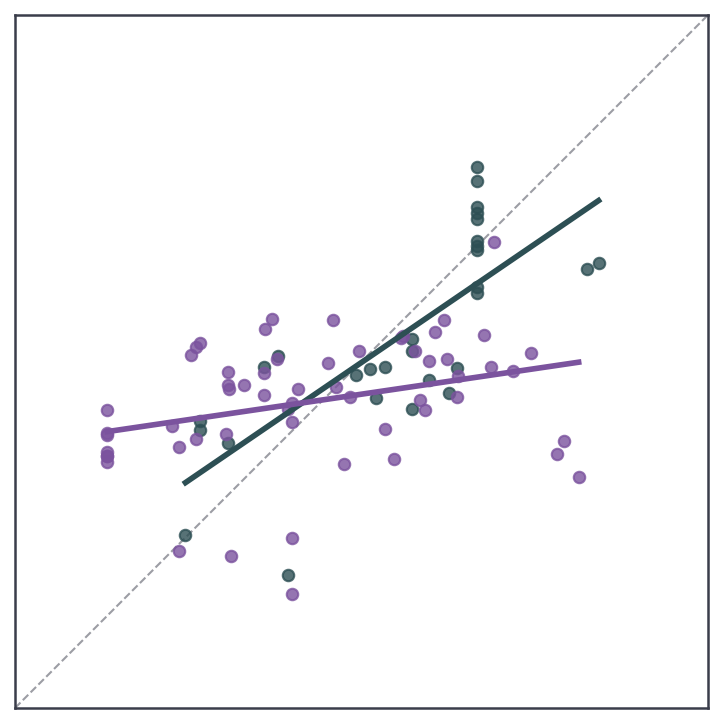

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(SIZE, SIZE))
LIM = (-11, -3.5)
POINT_COLOR = PLOT_PALETTE[1]
make_plot(preds_all.mean(axis=0), y, origin, ax)
ax.legend("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_box_aspect(1)

In [25]:
print("all on new")
get_metrics(y[origin == "new"], preds_all[:, origin == "new"])
print()
print("all on protacdb")
get_metrics(y[origin == "protacdb"], preds_all[:, origin == "protacdb"])
print()
print("new on new")
get_metrics(y[origin == "new"], preds_new[:, origin == "new"])
print()
print("new on protacdb")
get_metrics(y[origin == "protacdb"], preds_new[:, origin == "protacdb"])
print()
print("protacdb on new")
get_metrics(y[origin == "new"], preds_orig[:, origin == "new"])
print()
print("protacdb on protacdb")
get_metrics(y[origin == "protacdb"], preds_orig[:, origin == "protacdb"])

all on new
Spearman: 0.33 ± 0.06
RMSE: 1.40 ± 0.04
R²: 0.04 ± 0.05

all on protacdb
Spearman: 0.82 ± 0.03
RMSE: 0.82 ± 0.07
R²: 0.51 ± 0.08

new on new
Spearman: 0.30 ± 0.09
RMSE: 1.47 ± 0.05
R²: -0.07 ± 0.08

new on protacdb
Spearman: 0.80 ± 0.02
RMSE: 1.07 ± 0.04
R²: 0.18 ± 0.06

protacdb on new
Spearman: 0.12 ± 0.03
RMSE: 1.96 ± 0.03
R²: -0.88 ± 0.06

protacdb on protacdb
Spearman: 0.82 ± 0.06
RMSE: 0.67 ± 0.08
R²: 0.67 ± 0.08


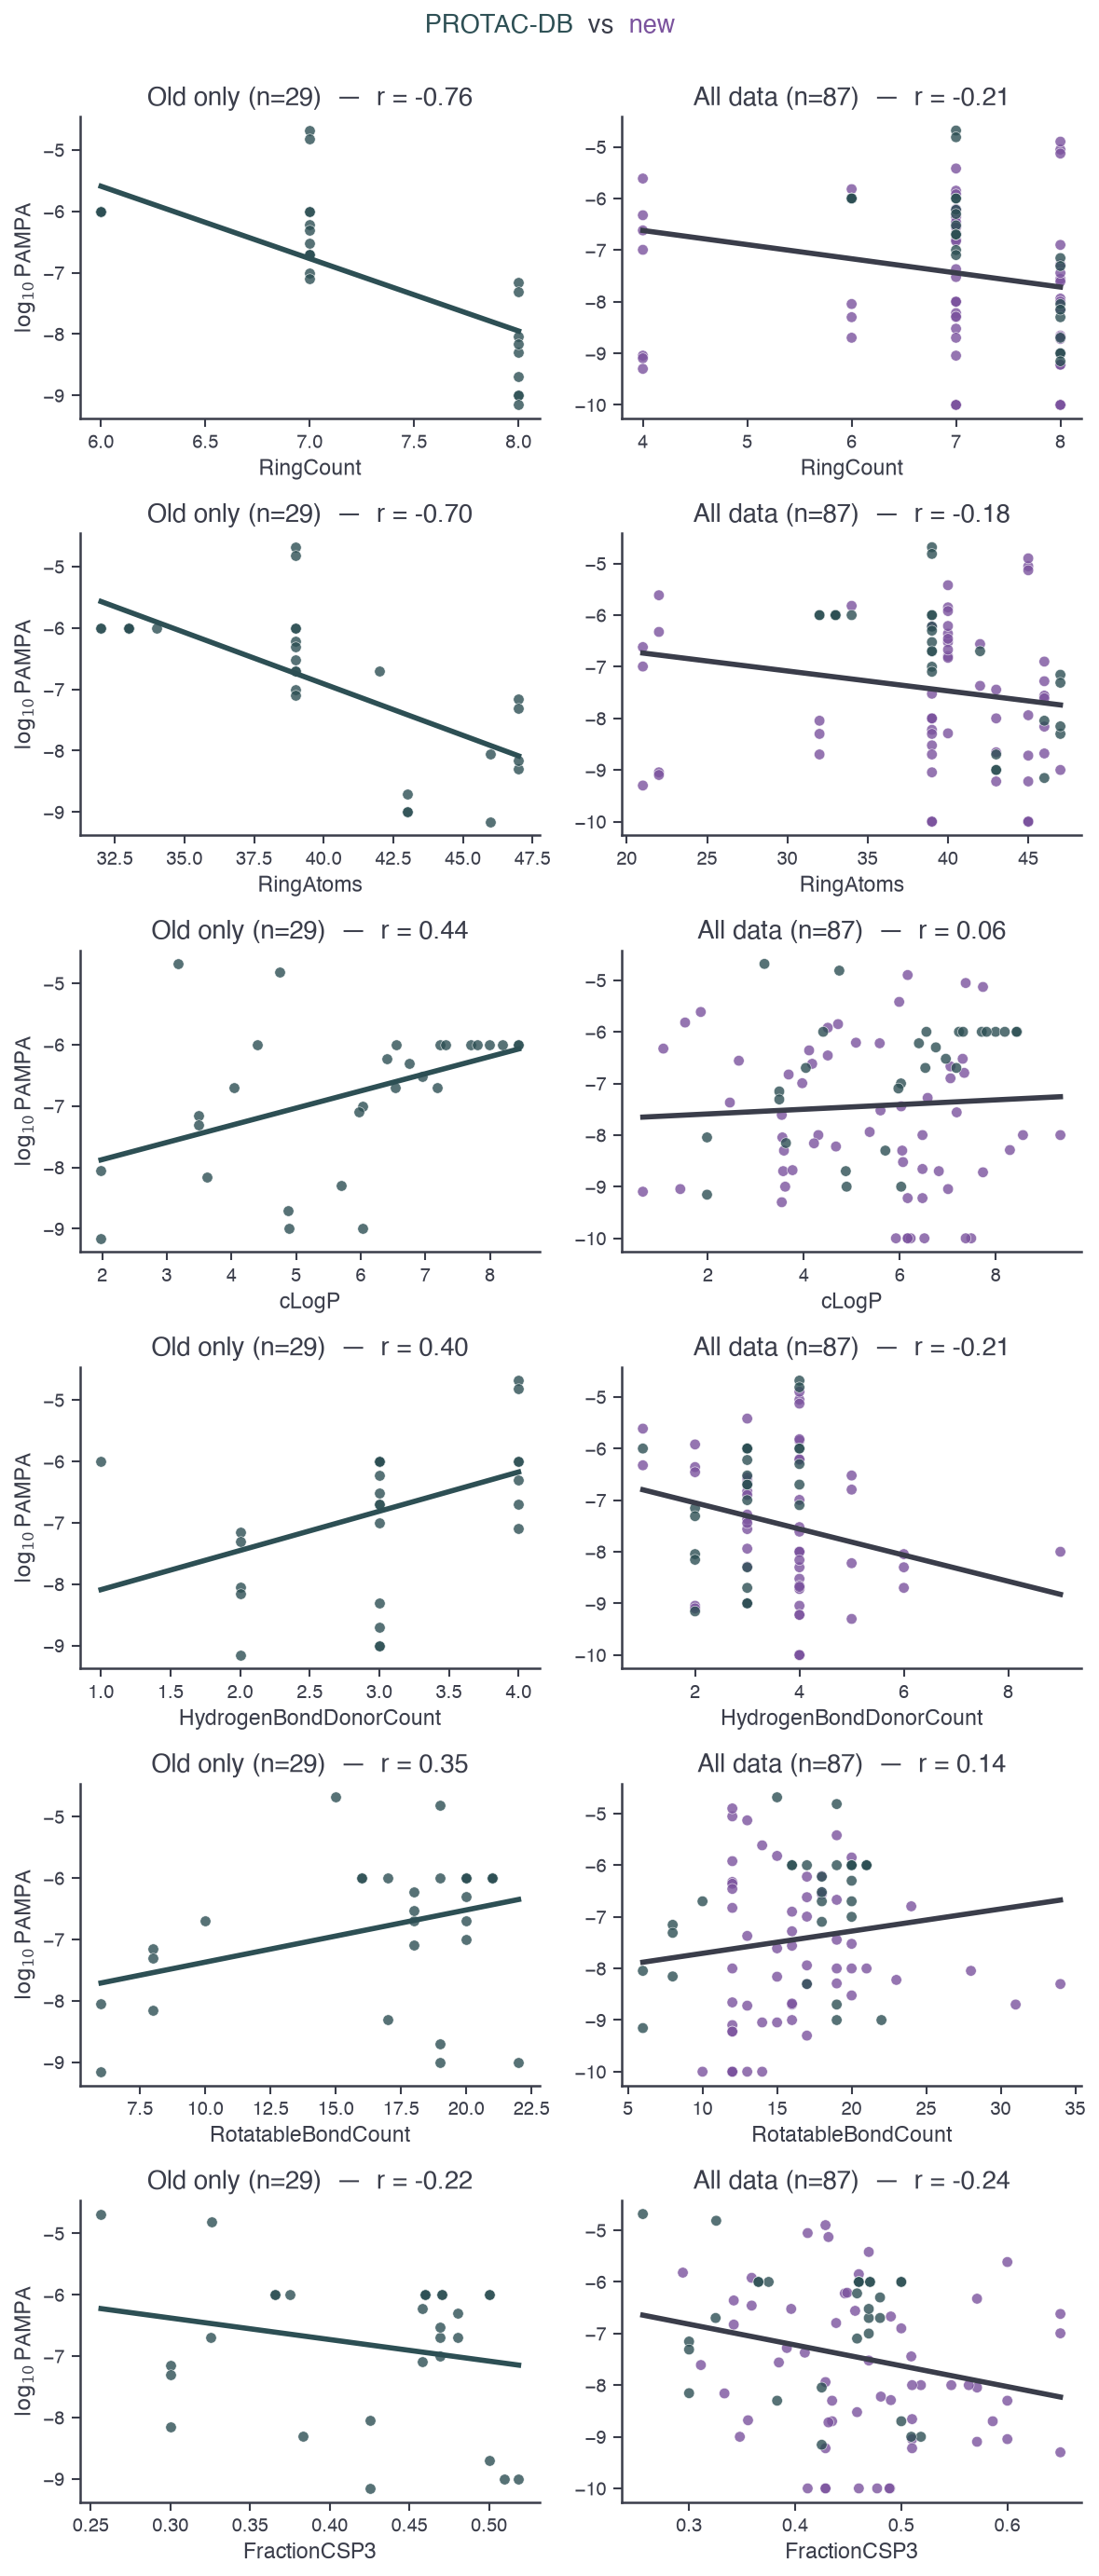

In [26]:
from scipy.stats import pearsonr

scatter_vars = [
    "RingCount",
    "RingAtoms",
    "cLogP",
    "HydrogenBondDonorCount",
    "RotatableBondCount",
    "FractionCSP3"
]

OLD_COLOR = PLOT_PALETTE[0]
NEW_COLOR = PLOT_PALETTE[1]

old_df = protacs_features_2d[protacs_features_2d.origin == "protacdb"]
all_df = protacs_features_2d
origin_display = all_df["origin"].map({"protacdb": "Old (PROTAC-DB)", "new": "New"})


def add_colored_title(fig, parts, y, fontsize=13):
    """Draw a horizontally centered title made of differently-colored text runs."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    texts, widths = [], []
    for text, color in parts:
        t = fig.text(0, y, text, fontsize=fontsize, color=color, transform=fig.transFigure, va="bottom")
        widths.append(t.get_window_extent(renderer=renderer).width / fig.bbox.width)
        texts.append(t)
    x = 0.5 - sum(widths) / 2
    for t, w in zip(texts, widths):
        t.set_position((x, y))
        x += w


fig, axes = plt.subplots(len(scatter_vars), 2, figsize=(8, 3.1 * len(scatter_vars)))
for row, var in enumerate(scatter_vars):
    ax = axes[row, 0]
    r_old, _ = pearsonr(old_df[var], old_df["logPAMPA"])
    sns.regplot(
        data=old_df, x=var, y="logPAMPA", ax=ax,
        scatter_kws={"color": OLD_COLOR, "alpha": 0.8, "s": 30, "edgecolors": "white", "linewidths": 0.3},
        line_kws={"color": OLD_COLOR}, ci=None
    )
    ax.set_title(f"Old only (n={len(old_df)})  —  r = {r_old:.2f}", color=DARK_SLATE)
    ax.set_ylabel(r"$\log_{10}$PAMPA")
    ax.set_xlabel(var)
    sns.despine(ax=ax)

    ax = axes[row, 1]
    r_all, _ = pearsonr(all_df[var], all_df["logPAMPA"])
    sns.regplot(
        data=all_df, x=var, y="logPAMPA", ax=ax,
        scatter=False, line_kws={"color": DARK_SLATE}, ci=None
    )
    sns.scatterplot(
        x=all_df[var], y=all_df["logPAMPA"], hue=origin_display,
        hue_order=["Old (PROTAC-DB)", "New"],
        palette={"Old (PROTAC-DB)": OLD_COLOR, "New": NEW_COLOR},
        alpha=0.8, s=30, edgecolor="white", linewidth=0.3, ax=ax, legend=False,
    )
    ax.set_title(f"All data (n={len(all_df)})  —  r = {r_all:.2f}", color=DARK_SLATE)
    ax.set_ylabel("")
    ax.set_xlabel(var)
    sns.despine(ax=ax)

plt.tight_layout(rect=(0, 0, 1, 0.97))
add_colored_title(
    fig,
    [("PROTAC-DB", OLD_COLOR), ("  vs  ", DARK_SLATE), ("new", NEW_COLOR)],
    y=0.98,
)
fig.savefig("../figures/old_vs_all_scatter.png", dpi=200, bbox_inches="tight")
